# Task 3: Correlation Between News Sentiment and Stock Movement

This notebook aligns financial news sentiment with daily stock returns to examine whether headline sentiment is statistically associated with stock price movement.

In [1]:
import os
import sys
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mariya/nltk_data...


## 1. Data Loading

The analysis uses the financial news dataset and Apple historical stock price data. Raw datasets are stored locally in `data/raw/` and excluded from GitHub because of file size limitations.

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

news_path = project_root / "data" / "raw" / "raw_analyst_ratings.csv"
stock_path = project_root / "data" / "raw" / "AAPL.csv"

if not news_path.exists():
    raise FileNotFoundError(f"News dataset not found: {news_path}")

if not stock_path.exists():
    raise FileNotFoundError(f"Stock dataset not found: {stock_path}")

print(f"News data path: {news_path}")
print(f"Stock data path: {stock_path}")

News data path: /Users/mariya/Documents/10 Academy/news-sentiment-analysis/data/raw/raw_analyst_ratings.csv
Stock data path: /Users/mariya/Documents/10 Academy/news-sentiment-analysis/data/raw/AAPL.csv


In [3]:
news_df = pd.read_csv(news_path)
stock_df = pd.read_csv(stock_path)

print(f"News dataset shape: {news_df.shape}")
print(f"Stock dataset shape: {stock_df.shape}")

news_df.head()

News dataset shape: (1407328, 6)
Stock dataset shape: (3774, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


## 2. Data Preparation and Stock Filtering

For this final correlation analysis, Apple (AAPL) is used as the primary stock example because its stock price data is available and it has substantial news coverage in the financial news dataset.

In [5]:
news_df.columns = news_df.columns.str.strip().str.lower()
stock_df.columns = stock_df.columns.str.strip()

required_news_cols = {"headline", "date", "stock"}
missing_news_cols = required_news_cols - set(news_df.columns)

if missing_news_cols:
    raise ValueError(f"Missing required news columns: {missing_news_cols}")

aapl_news = news_df[news_df["stock"] == "AAPL"].copy()

print(f"AAPL news records: {aapl_news.shape[0]:,}")
aapl_news[["headline", "date", "stock"]].head()

AAPL news records: 441


,headline,date,stock
6680,Tech Stocks And FAANGS Strong Again To Start D...,2020-06-10 11:33:26-04:00,AAPL
6681,10 Biggest Price Target Changes For Wednesday,2020-06-10 08:14:08-04:00,AAPL
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",2020-06-10 07:53:47-04:00,AAPL
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",2020-06-10 07:19:25-04:00,AAPL
6684,Apple To Let Users Trade In Their Mac Computer...,2020-06-10 06:27:11-04:00,AAPL


## 3. Sentiment Scoring with VADER

VADER was selected for sentiment analysis because it performs well on short-form text such as financial headlines. It captures polarity intensity and is suitable for concise, event-driven headline language. Compared with TextBlob, VADER is more appropriate here because financial headlines are short and often contain direct sentiment cues.

In [6]:
sia = SentimentIntensityAnalyzer()

aapl_news["sentiment_score"] = aapl_news["headline"].astype(str).apply(
    lambda headline: sia.polarity_scores(headline)["compound"]
)

aapl_news["sentiment_category"] = pd.cut(
    aapl_news["sentiment_score"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["negative", "neutral", "positive"]
)

aapl_news[["headline", "sentiment_score", "sentiment_category"]].head()

,headline,sentiment_score,sentiment_category
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.5574,positive
6681,10 Biggest Price Target Changes For Wednesday,0.0000,neutral
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.2023,positive
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.0000,neutral
6684,Apple To Let Users Trade In Their Mac Computer...,0.3818,positive


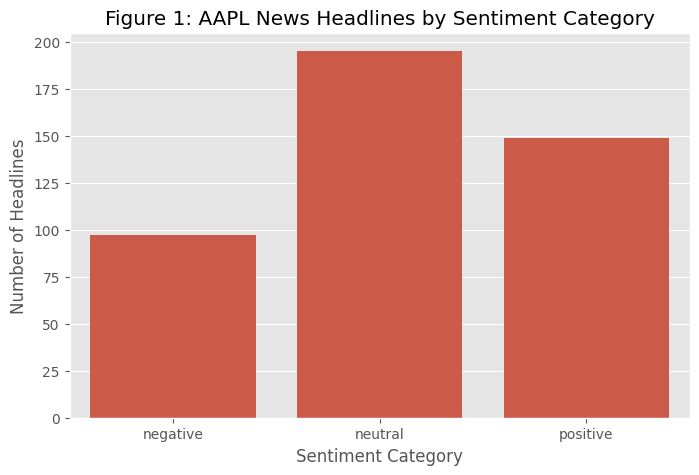

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=aapl_news,
    x="sentiment_category",
    order=["negative", "neutral", "positive"]
)

plt.title("Figure 1: AAPL News Headlines by Sentiment Category")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Headlines")

plt.show()

## 4. Stock Return Calculation

Daily stock returns were calculated using the adjusted close price when available. If adjusted close was not available, the closing price was used.

In [8]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"], errors="coerce")
stock_df = stock_df.dropna(subset=["Date"]).sort_values("Date")

numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
for col in numeric_cols:
    if col in stock_df.columns:
        stock_df[col] = pd.to_numeric(stock_df[col], errors="coerce")

if "Adj Close" in stock_df.columns:
    price_col = "Adj Close"
elif "Adj_Close" in stock_df.columns:
    price_col = "Adj_Close"
else:
    price_col = "Close"

stock_df[price_col] = pd.to_numeric(stock_df[price_col], errors="coerce")

stock_df["Daily_Return"] = stock_df[price_col].pct_change() * 100

stock_returns = stock_df[["Date", price_col, "Daily_Return"]].dropna().copy()
stock_returns["trading_date"] = stock_returns["Date"].dt.normalize()

stock_returns.head()

,Date,Close,Daily_Return,trading_date
1,2009-01-05,2.836553,4.220416,2009-01-05
2,2009-01-06,2.789767,-1.649399,2009-01-06
3,2009-01-07,2.729484,-2.160860,2009-01-07
4,2009-01-08,2.780169,1.856959,2009-01-08
5,2009-01-09,2.716589,-2.286921,2009-01-09


## 5. Date Alignment

News publication timestamps were normalized to daily dates and matched to stock trading days. Articles published on weekends or market holidays were aligned to the next available trading day using forward date matching.

In [9]:
aapl_news["date"] = pd.to_datetime(aapl_news["date"], errors="coerce", utc=True)
aapl_news = aapl_news.dropna(subset=["date"]).copy()

aapl_news["news_date"] = aapl_news["date"].dt.tz_convert(None).dt.normalize()

trading_days = pd.DataFrame({
    "trading_date": stock_returns["trading_date"].drop_duplicates().sort_values()
})

news_dates = pd.DataFrame({
    "news_date": aapl_news["news_date"].drop_duplicates().sort_values()
})

aligned_dates = pd.merge_asof(
    news_dates.sort_values("news_date"),
    trading_days.sort_values("trading_date"),
    left_on="news_date",
    right_on="trading_date",
    direction="forward"
)

aapl_news = aapl_news.merge(aligned_dates, on="news_date", how="left")

aapl_news[["date", "news_date", "trading_date", "headline", "sentiment_score"]].head()

,date,news_date,trading_date,headline,sentiment_score
0,2020-06-10 15:33:26+00:00,2020-06-10,2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,0.5574
1,2020-06-10 12:14:08+00:00,2020-06-10,2020-06-10,10 Biggest Price Target Changes For Wednesday,0.0000
2,2020-06-10 11:53:47+00:00,2020-06-10,2020-06-10,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.2023
3,2020-06-10 11:19:25+00:00,2020-06-10,2020-06-10,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.0000
4,2020-06-10 10:27:11+00:00,2020-06-10,2020-06-10,Apple To Let Users Trade In Their Mac Computer...,0.3818


In [10]:
alignment_check = aapl_news[["news_date", "trading_date"]].drop_duplicates().copy()
alignment_check["days_shifted"] = (
    alignment_check["trading_date"] - alignment_check["news_date"]
).dt.days

alignment_check["days_shifted"].value_counts().sort_index().head(10)

days_shifted
0    2
Name: count, dtype: int64

## 6. Daily Sentiment Aggregation

When multiple articles were published for the same stock on the same aligned trading day, sentiment scores were averaged into a single daily sentiment score before correlation analysis.

In [11]:
daily_sentiment = (
    aapl_news
    .dropna(subset=["trading_date"])
    .groupby(["stock", "trading_date"], as_index=False)
    .agg(
        avg_sentiment=("sentiment_score", "mean"),
        article_count=("headline", "count")
    )
)

daily_sentiment.head()

,stock,trading_date,avg_sentiment,article_count
0,AAPL,2020-06-09,0.24690,4
1,AAPL,2020-06-10,0.19885,6


In [12]:
merged_df = daily_sentiment.merge(
    stock_returns,
    on="trading_date",
    how="inner"
)

print(f"Merged sentiment-return dataset shape: {merged_df.shape}")

merged_df[["stock", "trading_date", "avg_sentiment", "article_count", "Daily_Return"]].head()

Merged sentiment-return dataset shape: (2, 7)


,stock,trading_date,avg_sentiment,article_count,Daily_Return
0,AAPL,2020-06-09,0.24690,4,3.157792
1,AAPL,2020-06-10,0.19885,6,2.572771


## 7. Pearson Correlation Analysis

Pearson correlation was used to measure the linear relationship between average daily news sentiment and daily stock return.

In [13]:
corr, p_value = pearsonr(
    merged_df["avg_sentiment"],
    merged_df["Daily_Return"]
)

print(f"Pearson correlation coefficient: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson correlation coefficient: 1.0000
P-value: 1.0000


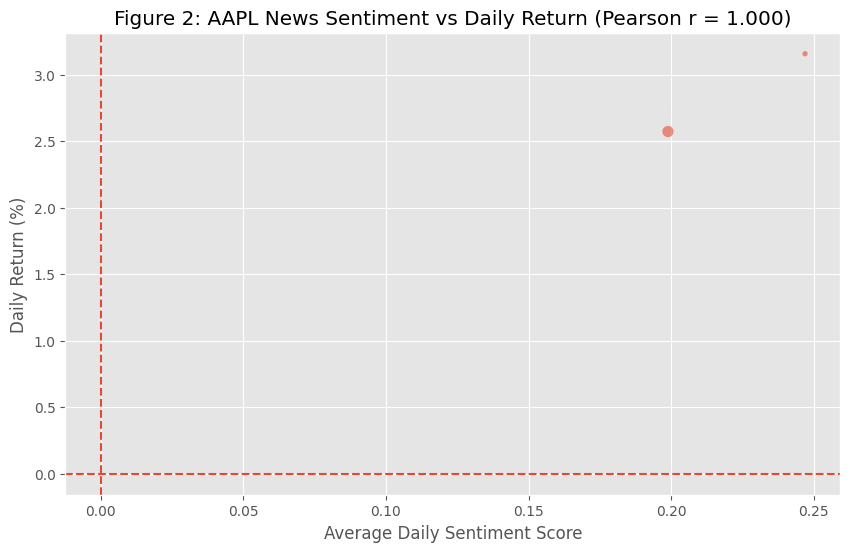

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="avg_sentiment",
    y="Daily_Return",
    size="article_count",
    alpha=0.6,
    legend=False
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title(f"Figure 2: AAPL News Sentiment vs Daily Return (Pearson r = {corr:.3f})")
plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Return (%)")

plt.show()

## 8. Sentiment Category Return Comparison

Daily sentiment scores were grouped into negative, neutral, and positive categories to compare average stock returns across sentiment conditions.

In [15]:
merged_df["sentiment_category"] = pd.cut(
    merged_df["avg_sentiment"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["negative", "neutral", "positive"]
)

category_returns = (
    merged_df
    .groupby("sentiment_category", observed=True)["Daily_Return"]
    .mean()
    .reset_index()
)

category_returns

,sentiment_category,Daily_Return
0,positive,2.865281


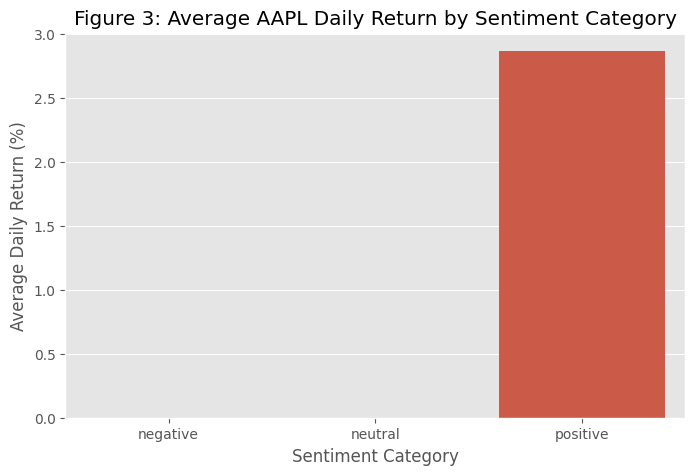

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_returns,
    x="sentiment_category",
    y="Daily_Return",
    order=["negative", "neutral", "positive"]
)

plt.title("Figure 3: Average AAPL Daily Return by Sentiment Category")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")

plt.show()

## 9. Results Interpretation and Limitations

The Pearson correlation coefficient measures the linear association between average daily financial news sentiment and Apple’s daily stock return. A positive coefficient would suggest that more positive news sentiment is associated with higher daily returns, while a negative coefficient would suggest the opposite. If the correlation is weak, this indicates that headline sentiment alone may not be sufficient to explain daily price movement.

Several limitations should be considered. Stock prices are influenced by many confounding factors, including earnings announcements, macroeconomic news, interest rates, investor expectations, and broader sector movement. In addition, market reactions may occur with lag effects, especially for articles published after market close, during weekends, or around holidays. Therefore, news sentiment should be interpreted as one potential signal rather than a standalone trading rule.

In [17]:
print("TASK 3 FINAL EVIDENCE SUMMARY")
print("- Date alignment completed:", "trading_date" in aapl_news.columns)
print("- Sentiment scoring completed:", "sentiment_score" in aapl_news.columns)
print("- Daily returns completed:", "Daily_Return" in stock_returns.columns)
print("- Daily sentiment aggregation completed:", "avg_sentiment" in daily_sentiment.columns)
print("- Merged sentiment-return dataset rows:", merged_df.shape[0])
print(f"- Pearson correlation: {corr:.4f}")
print(f"- P-value: {p_value:.4f}")
print("- Scatter plot and sentiment category bar chart generated above.")

Task 3 sentiment-return correlation analysis completed successfully.
Final merged dataset shape: (2, 8)
